 ## =============================================================================  
 本文件的部分代码（推理部分的代码）直接取自 MedSAM 项目。  
 原始来源: https://github.com/bowang-lab/MedSAM/blob/main/tutorial_quickstart.ipynb  
        https://colab.research.google.com/drive/19WNtRMbpsxeqimBlmJwtd1dzpaIvK2FZ?usp=sharing  
 许可证: Apache License, Version 2.0  
 版权所有 (c)  Ma, Jun et al.   
 该部分代码未做任何修改，在此仅作功能集成。  
 
 ## =============================================================================  

# 沐曦GPU运行MedSAM说明文档

[MedSAM](https://github.com/bowang-lab/MedSAM)是专为医学图像分割设计的 Segment Anything 模型变体。本文档介绍如何在沐曦 GPU 上安装运行 `MedSAM`。

## 1. 安装
### 1.1 安装monai
> 请参考[沐曦GPU运行MONAI 1.5.2说明文档](https://github.com/MetaX-MACA/MedicalImage/blob/main/MONAI/README.md) 安装monai  
> 为简化环境部署，后续会在沐曦开发者社区提供`MONAI镜像`，请关注[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。

### 1.2 下载并安装MedSAM

In [ ]:
%%bash
cd /opt 
git clone https://github.com/bowang-lab/MedSAM.git MedSAM
cd MedSAM && sed -i '/cmdclass={/,/},/d' setup.py && pip install .

### 1.3 环境验证

In [10]:
import torch
assert torch.cuda.is_available()
print('PyTorch version:', torch.__version__)
print('CUDA OK:', torch.cuda.get_device_name(0))

PyTorch version: 2.8.0+metax3.8.0.7
CUDA OK: MetaX C500


### 1.4 下载权重
下载模型权重文件[model checkpoint](https://drive.google.com/drive/folders/1ETWmi4AiniJeWOt6HAsYgTjYv_fkgzoN?usp=drive_link)，并将其放置在工作目录下，例如 `/opt/MedSAM/medsam_vit_b.pth`

## 2. 沐曦GPU 运行效果展示
### 2.1 非交互式推理

In [11]:
# %% environment and functions
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F

os.chdir('/opt/MedSAM')
# visualization functions
# source: https://github.com/facebookresearch/segment-anything/blob/main/notebooks/predictor_example.ipynb
# change color to avoid red and green
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2))

@torch.no_grad()
def medsam_inference(medsam_model, img_embed, box_1024, H, W):
    box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=img_embed.device)
    if len(box_torch.shape) == 2:
        box_torch = box_torch[:, None, :] # (B, 1, 4)

    sparse_embeddings, dense_embeddings = medsam_model.prompt_encoder(
        points=None,
        boxes=box_torch,
        masks=None,
    )
    low_res_logits, _ = medsam_model.mask_decoder(
        image_embeddings=img_embed, # (B, 256, 64, 64)
        image_pe=medsam_model.prompt_encoder.get_dense_pe(), # (1, 256, 64, 64)
        sparse_prompt_embeddings=sparse_embeddings, # (B, 2, 256)
        dense_prompt_embeddings=dense_embeddings, # (B, 256, 64, 64)
        multimask_output=False,
        )

    low_res_pred = torch.sigmoid(low_res_logits)  # (1, 1, 256, 256)

    low_res_pred = F.interpolate(
        low_res_pred,
        size=(H, W),
        mode="bilinear",
        align_corners=False,
    )  # (1, 1, gt.shape)
    low_res_pred = low_res_pred.squeeze().cpu().numpy()  # (256, 256)
    medsam_seg = (low_res_pred > 0.5).astype(np.uint8)
    return medsam_seg



In [12]:
#%% load model and image
MedSAM_CKPT_PATH = "/opt/MedSAM/medsam_vit_b.pth"
device = "cuda:0"
medsam_model = sam_model_registry['vit_b'](checkpoint=MedSAM_CKPT_PATH)
medsam_model = medsam_model.to(device)
medsam_model.eval()

img_np = io.imread('assets/img_demo.png')
if len(img_np.shape) == 2:
    img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
else:
    img_3c = img_np
H, W, _ = img_3c.shape

In [13]:
#%% image preprocessing and model inference
img_1024 = transform.resize(img_3c, (1024, 1024), order=3, preserve_range=True, anti_aliasing=True).astype(np.uint8)
img_1024 = (img_1024 - img_1024.min()) / np.clip(
    img_1024.max() - img_1024.min(), a_min=1e-8, a_max=None
)  # normalize to [0, 1], (H, W, 3)
# convert the shape to (3, H, W)
img_1024_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(device)

box_np = np.array([[95,255, 190, 350]])
# transfer box_np t0 1024x1024 scale
box_1024 = box_np / np.array([W, H, W, H]) * 1024
with torch.no_grad():
    image_embedding = medsam_model.image_encoder(img_1024_tensor) # (1, 256, 64, 64)

medsam_seg = medsam_inference(medsam_model, image_embedding, box_1024, H, W)

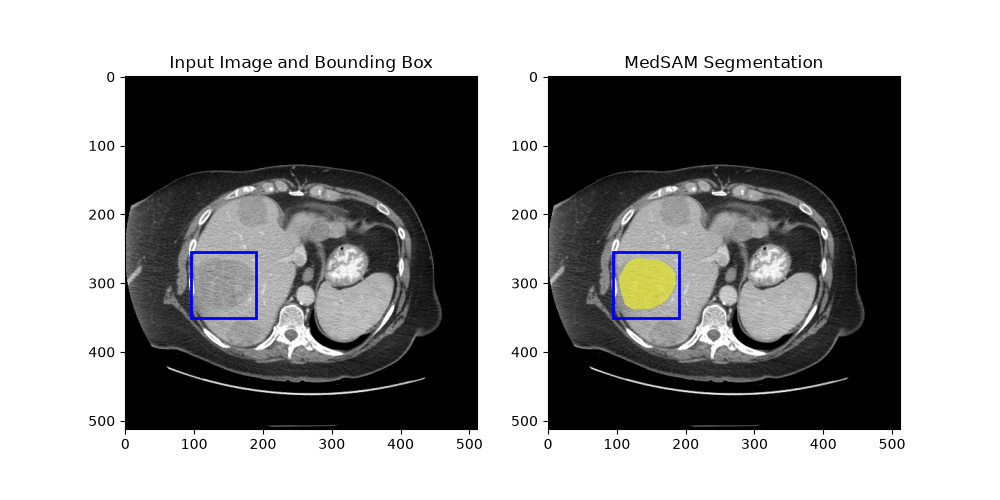

In [14]:
#%% visualize results
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_3c)
show_box(box_np[0], ax[0])
ax[0].set_title("Input Image and Bounding Box")
ax[1].imshow(img_3c)
show_mask(medsam_seg, ax[1])
show_box(box_np[0], ax[1])
ax[1].set_title("MedSAM Segmentation")
plt.show()

### 2.2 交互式推理

In [15]:
%matplotlib widget
from segment_anything import sam_model_registry
from utils.demo import BboxPromptDemo
MedSAM_CKPT_PATH = "/opt/MedSAM/medsam_vit_b.pth"
device = "cuda:0"
medsam_model = sam_model_registry['vit_b'](checkpoint=MedSAM_CKPT_PATH)
medsam_model = medsam_model.to(device)
medsam_model.eval()

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


Button(description='clear', style=ButtonStyle())

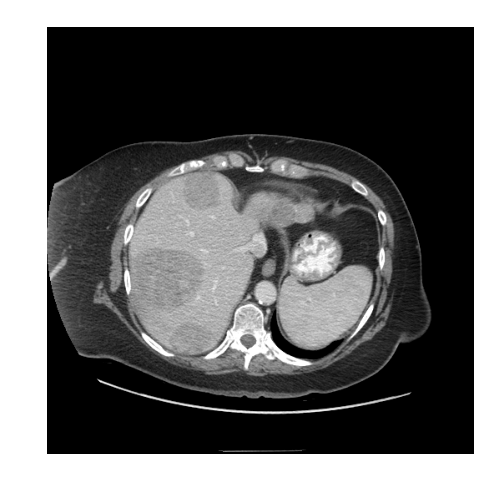

Button(description='save', style=ButtonStyle())

In [16]:
# abdomen CT
img = "assets/img_demo.png"
bbox_prompt_demo = BboxPromptDemo(medsam_model)
bbox_prompt_demo.show(img)

Button(description='clear', style=ButtonStyle())

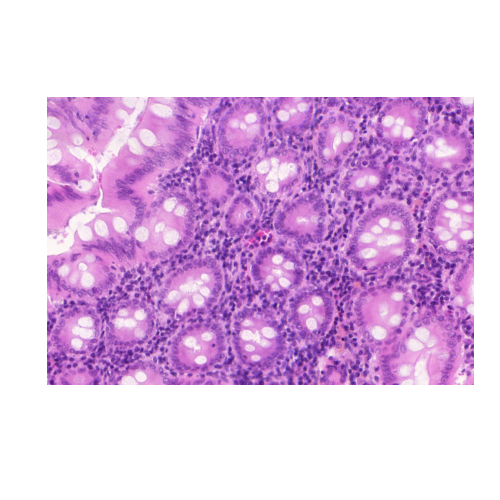

Button(description='save', style=ButtonStyle())

In [17]:
# colon gland pathology image
# important: please re-run this cell to avoid using the above image embedding.
img = "assets/pathology.png"
bbox_prompt_demo = BboxPromptDemo(medsam_model)
bbox_prompt_demo.show(img)

---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。
### Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.
